<a href="https://colab.research.google.com/github/AI-fanatic24/machine-learning-foundations/blob/main/Diabetes_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
import math
from sklearn.metrics import r2_score

In [ ]:
df = pd.read_csv('/content/diabetes_train - logistic regression.csv')
df

,BMI,Outcome
0,33.6,1
1,38.2,1
2,44.2,1
3,42.3,1
4,40.7,1
...,...,...
143,32.8,1
144,0.0,0
145,32.8,1
146,30.5,1


In [ ]:
x_train = np.array(df[['BMI']])
x_train

array([[33.6],
       [38.2],
       [44.2],
       [42.3],
       [40.7],
       [46.5],
       [25.6],
       [26.1],
       [36.8],
       [33.5],
       [32.8],
       [28.9],
       [ 0. ],
       [26.6],
       [26. ],
       [30.1],
       [25.1],
       [29.3],
       [25.2],
       [37.2],
       [39. ],
       [33.3],
       [37.3],
       [33.3],
       [36.5],
       [28.6],
       [30.4],
       [25. ],
       [29.7],
       [22.1],
       [24.2],
       [27.3],
       [25.6],
       [31.6],
       [27.6],
       [24. ],
       [33.2],
       [32.9],
       [38.2],
       [37.1],
       [34. ],
       [40.2],
       [22.7],
       [45.4],
       [27.4],
       [42. ],
       [29.7],
       [28. ],
       [39.1],
       [14.5],
       [20. ],
       [15.5],
       [18. ],
       [17. ],
       [19. ],
       [12.9],
       [21.1],
       [20.2],
       [19.2],
       [ 0. ],
       [32.9],
       [25. ],
       [25.4],
       [32.8],
       [29. ],
       [32.5],
       [42

In [ ]:
y_train = np.array(df[['Outcome']])
y_train

array([[1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
    

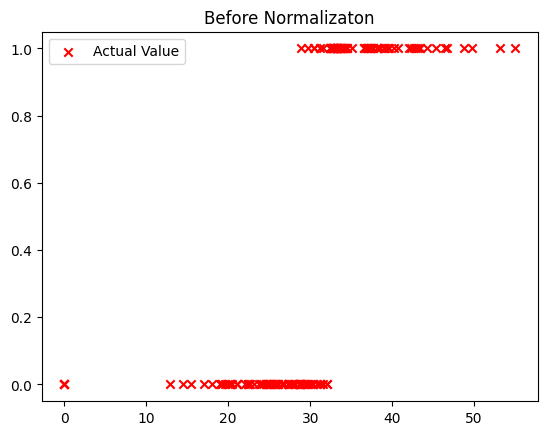

In [ ]:
plt.scatter(x_train,y_train,marker='x',c='r',label='Actual Value')
plt.title('Before Normalizaton')
plt.legend()
plt.show()

In [ ]:
def zscore_normalize(X):
  mu = np.mean(X,axis=0)
  sigma = np.std(X,axis=0)
  x_norm = (X-mu)/sigma
  return x_norm

In [ ]:
x_norm = zscore_normalize(x_train)
x_norm

array([[ 3.44475109e-01],
       [ 8.51213774e-01],
       [ 1.51217725e+00],
       [ 1.30287215e+00],
       [ 1.12661522e+00],
       [ 1.76554658e+00],
       [-5.36809526e-01],
       [-4.81729236e-01],
       [ 6.96988963e-01],
       [ 3.33459051e-01],
       [ 2.56346645e-01],
       [-1.73279614e-01],
       [-3.35692036e+00],
       [-4.26648947e-01],
       [-4.92745294e-01],
       [-4.10869188e-02],
       [-5.91889816e-01],
       [-1.29215382e-01],
       [-5.80873758e-01],
       [ 7.41053195e-01],
       [ 9.39342238e-01],
       [ 3.11426935e-01],
       [ 7.52069253e-01],
       [ 3.11426935e-01],
       [ 6.63940789e-01],
       [-2.06327788e-01],
       [-8.03874498e-03],
       [-6.02905874e-01],
       [-8.51511505e-02],
       [-9.22371554e-01],
       [-6.91034337e-01],
       [-3.49536541e-01],
       [-5.36809526e-01],
       [ 1.24153950e-01],
       [-3.16488367e-01],
       [-7.13066453e-01],
       [ 3.00410877e-01],
       [ 2.67362703e-01],
       [ 8.5

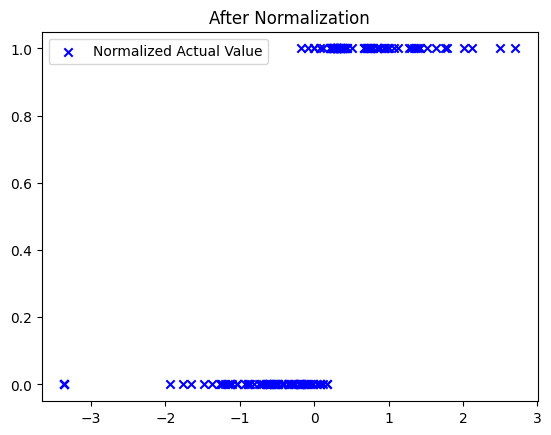

In [ ]:
plt.scatter(x_norm,y_train,marker='x',c='b',label='Normalized Actual Value')
plt.title('After Normalization')
plt.legend()
plt.show()

In [ ]:
def sigmoid(z):
  g_z = 1/(1+np.exp(-z))
  return g_z

In [ ]:
def compute_cost(x,y,w,b):
  m = x.shape[0]
  cost = 0.0
  for i in range(m):
    z_i = np.dot(x[i],w)+b
    f_i = sigmoid(z_i)
    cost += -y[i]*np.log(f_i) - (1-y[i])*np.log(1-f_i)
  cost = cost/m
  return cost

In [ ]:
cost = compute_cost(x_norm,y_train,1,1)
cost

array([0.53503455])

In [ ]:
def compute_gradient(x,y,w,b):
  m = x.shape[0]
  dj_dw = 0
  dj_db = 0
  for i in range(m):
    f_i = sigmoid(np.dot(x[i],w)+b)
    err = f_i - y[i]
    dj_dw = dj_dw + (err*x[i])
    dj_db = dj_db + err
  dj_dw = dj_dw/m
  dj_db = dj_db/m
  return dj_dw, dj_db

In [ ]:
dj_dw,dj_db = compute_gradient(x_norm,y_train,0,0)
print(dj_dw,dj_db)

[-0.35955077] [-0.01351351]


In [ ]:
def gradient_descent(x,y,w_in,b_in,alpha,iters):
  J_hist = []
  w = copy.deepcopy(w_in)
  b = b_in
  for i in range(iters):
    dj_dw,dj_db = compute_gradient(x,y,w,b)

    w = w - alpha*dj_dw
    b = b - alpha*dj_db

    if i<100000:
      J_hist.append(compute_cost(x,y,w,b))
    if i%math.ceil(iters/10) == 0:
      print(f"Iteration{i:4d} : Cost{J_hist[-1]}")
  return w,b,J_hist

In [ ]:
w_tmp=0
b_tmp=0
alph = 0.001
num_iters = 100000
w,b,_ = gradient_descent(x_norm,y_train,w_tmp,b_tmp,alph,num_iters)
print(w)
print(b)

Iteration   0 : Cost[0.69301774]
Iteration10000 : Cost[0.33928748]
Iteration20000 : Cost[0.27139244]
Iteration30000 : Cost[0.23856731]
Iteration40000 : Cost[0.21836988]
Iteration50000 : Cost[0.20438721]
Iteration60000 : Cost[0.19400063]
Iteration70000 : Cost[0.18591472]
Iteration80000 : Cost[0.17940539]
Iteration90000 : Cost[0.17403186]
[5.27413715]
[-0.12413391]


In [ ]:
b = float(b)
b

-0.12413391261602173

In [ ]:
x_norm.shape

(148, 1)

In [ ]:
def predict(x,w,b):
  pred = []
  m = x.shape[0]
  for i in range(m):
    res = sigmoid(np.dot(x[i],w)+b)
    if res >= 0.5:
      pred.append(1)
      print("Prediction -> 1 : Actual Value ->",y_train[i])
    else:
      pred.append(0)
      print("Prediction -> 0 : Actual Value ->",y_train[i])
  return pred

In [ ]:
pred = predict(x_norm,w,b)

Prediction -> 1 : Actual Value -> [1]
Prediction -> 1 : Actual Value -> [1]
Prediction -> 1 : Actual Value -> [1]
Prediction -> 1 : Actual Value -> [1]
Prediction -> 1 : Actual Value -> [1]
Prediction -> 1 : Actual Value -> [1]
Prediction -> 0 : Actual Value -> [0]
Prediction -> 0 : Actual Value -> [0]
Prediction -> 1 : Actual Value -> [1]
Prediction -> 1 : Actual Value -> [1]
Prediction -> 1 : Actual Value -> [1]
Prediction -> 0 : Actual Value -> [1]
Prediction -> 0 : Actual Value -> [0]
Prediction -> 0 : Actual Value -> [0]
Prediction -> 0 : Actual Value -> [0]
Prediction -> 0 : Actual Value -> [0]
Prediction -> 0 : Actual Value -> [0]
Prediction -> 0 : Actual Value -> [0]
Prediction -> 0 : Actual Value -> [0]
Prediction -> 1 : Actual Value -> [1]
Prediction -> 1 : Actual Value -> [1]
Prediction -> 1 : Actual Value -> [1]
Prediction -> 1 : Actual Value -> [1]
Prediction -> 1 : Actual Value -> [1]
Prediction -> 1 : Actual Value -> [1]
Prediction -> 0 : Actual Value -> [0]
Prediction -

In [ ]:
pred = np.array(pred)
pred_ = pred.reshape(-1,1)
pred_

array([[1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
    

In [ ]:
score_train = r2_score(y_train, pred_)
print("this model has",round(score_train,2)*100,"% traning accuracy")

this model has 73.0 % traning accuracy


Testing the model on test set

In [ ]:
df_test = pd.read_csv('/content/diabetes_test - logistic regression.csv')

In [ ]:
x_test = np.array(df_test[['BMI']])
y_test = np.array(df_test[['Outcome']])

In [ ]:
x_test

array([[32.9],
       [28.6],
       [43.4],
       [35.1],
       [32. ],
       [24.7],
       [32.6],
       [37.7],
       [43.2],
       [25. ],
       [22.4],
       [ 0. ],
       [29.3],
       [24.6],
       [48.8],
       [32.4],
       [36.6],
       [38.5],
       [37.1]])

In [ ]:
y_test

array([[1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1]])

In [ ]:
x_test_norm = zscore_normalize(x_test)

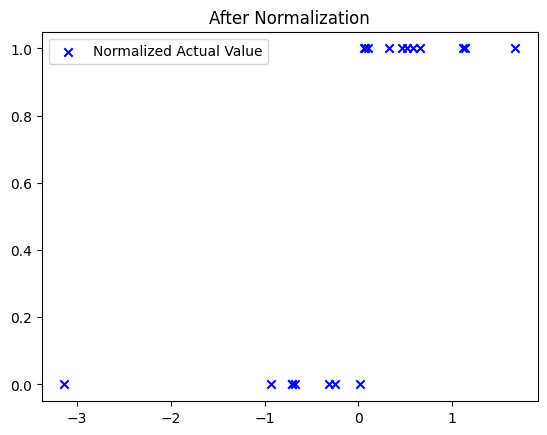

In [ ]:
plt.scatter(x_test_norm,y_test,marker='x',c='b',label='Normalized Actual Value')
plt.title('After Normalization')
plt.legend()
plt.show()

In [ ]:
print(w,b)

[5.27413715] -0.12413391261602173


In [ ]:
def predict_test(x,w,b):
  pred_test = []
  m = x.shape[0]
  for i in range(m):
    res = sigmoid(np.dot(x[i],w)+b)
    if res >= 0.5:
      pred_test.append(1)
      print("Prediction -> 1 : Actual Value ->",y_test[i])
    else:
      pred_test.append(0)
      print("Prediction -> 0 : Actual Value ->",y_test[i])
  return pred_test

In [ ]:
pred_test = predict_test(x_test_norm,w,b)

Prediction -> 1 : Actual Value -> [1]
Prediction -> 0 : Actual Value -> [0]
Prediction -> 1 : Actual Value -> [1]
Prediction -> 1 : Actual Value -> [1]
Prediction -> 0 : Actual Value -> [0]
Prediction -> 0 : Actual Value -> [0]
Prediction -> 1 : Actual Value -> [1]
Prediction -> 1 : Actual Value -> [1]
Prediction -> 1 : Actual Value -> [1]
Prediction -> 0 : Actual Value -> [0]
Prediction -> 0 : Actual Value -> [0]
Prediction -> 0 : Actual Value -> [0]
Prediction -> 0 : Actual Value -> [0]
Prediction -> 0 : Actual Value -> [0]
Prediction -> 1 : Actual Value -> [1]
Prediction -> 1 : Actual Value -> [1]
Prediction -> 1 : Actual Value -> [1]
Prediction -> 1 : Actual Value -> [1]
Prediction -> 1 : Actual Value -> [1]


In [ ]:
pred_test_ = np.array(pred_test)
pred_test_ = pred_test_.reshape(-1,1)
pred_test_

array([[1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1]])

In [ ]:
score_train = r2_score(y_test, pred_test_)
print("this model has",round(score_train,2)*100,"% testing accuracy")

this model has 100.0 % testing accuracy
